# MB-OSA and Adaptive Slice-Width Mapping
This notebook analyzes native 1/2/4-bit MB-OSA simulations and the 8-bit analog reference. Total input and weight precision remains 8 bits. Accuracy is **NOT_MODELED** and is never used for selection.

In [1]:
import json, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
run_dir = Path(os.environ['OPTICALLOOP_MULTISLICE_RUN_DIR']).resolve()
artifacts = run_dir / 'artifacts-multislice'
metadata = json.loads((run_dir / 'run.json').read_text())
fixed = pd.read_csv(artifacts / 'fixed_width_summary.csv')
aswm = pd.read_csv(artifacts / 'aswm_summary.csv')
selections = pd.read_csv(artifacts / 'aswm_layer_selections.csv')
checks = pd.read_csv(artifacts / 'validation.csv')
metadata['tier'], metadata['successful_jobs'], metadata['expected_jobs']

('full', 14080, 14080)

## Reproduced configuration and coverage

In [2]:
manifest = metadata['manifest']
configuration = pd.DataFrame(manifest['architectures']).set_index('name')
coverage = fixed.groupby(['network', 'variant', 'architecture']).layers.max().unstack('variant')
display(configuration)
display(coverage)
assert metadata['successful_jobs'] == metadata['expected_jobs']
assert checks.loc[checks.status == 'FAIL'].empty

,candidate,cols,pes,rows,tiles
name,,,,,
deap_high_channel,False,9,1,113,1
deap_wide_kernel,False,100,1,12,1
compact_4x4,True,4,64,4,1
c4_r8,True,4,32,8,1
c4_r16,True,4,16,16,1
c4_r32,True,4,8,32,1
c8_r4,True,8,32,4,1
paper_optimum_8x8,True,8,16,8,1
c8_r16,True,8,8,16,1


variant                               analog8  mbosa1  mbosa2  mbosa4
network            architecture                                      
alexnet            c4_r16                   8       8       8       8
                   c4_r32                   8       8       8       8
                   c4_r8                    8       8       8       8
                   c8_r16                   8       8       8       8
                   c8_r32                   8       8       8       8
                   c8_r4                    8       8       8       8
                   compact_4x4              8       8       8       8
                   deap_high_channel        8       8       8       8
                   deap_wide_kernel         8       8       8       8
                   paper_optimum_8x8        8       8       8       8
gpt2_medium        c4_r16                 145     145     145     145
                   c4_r32                 145     145     145     145
                   c4_r8                  145     145     145     145
                   c8_r16                 145     145     145     145
                   c8_r32                 145     145     145     145
                   c8_r4                  145     145     145     145
                   compact_4x4            145     145     145     145
                   deap_high_channel      145     145     145     145
                   deap_wide_kernel       145     145     145     145
                   paper_optimum_8x8      145     145     145     145
mobilenet_v3       c4_r16                  64      64      64      64
                   c4_r32                  64      64      64      64
                   c4_r8                   64      64      64      64
                   c8_r16                  64      64      64      64
                   c8_r32                  64      64      64      64
                   c8_r4                   64      64      64      64
                   compact_4x4             64      64      64      64
                   deap_high_channel       64      64      64      64
                   deap_wide_kernel        64      64      64      64
                   paper_optimum_8x8       64      64      64      64
resnet18           c4_r16                  21      21      21      21
                   c4_r32                  21      21      21      21
                   c4_r8                   21      21      21      21
                   c8_r16                  21      21      21      21
                   c8_r32                  21      21      21      21
                   c8_r4                   21      21      21      21
                   compact_4x4             21      21      21      21
                   deap_high_channel       21      21      21      21
                   deap_wide_kernel        21      21      21      21
                   paper_optimum_8x8       21      21      21      21
vgg16              c4_r16                  16      16      16      16
                   c4_r32                  16      16      16      16
                   c4_r8                   16      16      16      16
                   c8_r16                  16      16      16      16
                   c8_r32                  16      16      16      16
                   c8_r4                   16      16      16      16
                   compact_4x4             16      16      16      16
                   deap_high_channel       16      16      16      16
                   deap_wide_kernel        16      16      16      16
                   paper_optimum_8x8       16      16      16      16
vision_transformer c4_r16                  98      98      98      98
                   c4_r32                  98      98      98      98
                   c4_r8                   98      98      98      98
                   c8_r16                  98      98      98      98
                   c8_r32                  98      98      98      98
          

## Validation and accuracy boundary

In [3]:
display(checks)
assert fixed.accuracy_status.eq('NOT_MODELED').all()
assert aswm.accuracy_status.eq('NOT_MODELED').all()

,check,severity,status,detail
0,job_coverage,ERROR,PASS,14080/14080
1,no_duplicate_jobs,ERROR,PASS,unique=14080
2,exact_expected_jobs,ERROR,PASS,"missing=0, unexpected=0"
3,no_failed_job_results,ERROR,PASS,"result_files=14080, failed=0"
4,supported_slice_widths,ERROR,PASS,"[np.int64(1), np.int64(2), np.int64(4), np.int..."
5,temporal_slice_counts,ERROR,PASS,expected 8/4/2/1
6,accuracy_not_modeled,ERROR,PASS,NOT_MODELED
7,workload_layer_completeness,ERROR,PASS,"{""alexnet"": {""missing"": 0, ""unexpected"": 0}, ""..."
8,architecture_constraints,ERROR,PASS,"invalid_candidates=[], shape_mismatches=0"
9,unit_consistency,ERROR,PASS,"positive=True, max_latency_relative=0.000e+00"


## Primary 5.2 pJ/bit model

In [4]:
primary_fixed = fixed[(fixed.energy_model == 'linear_bit') & (fixed.optical_loss_db_per_stage == 0)]
primary_aswm = aswm[(aswm.energy_model == 'linear_bit') & (aswm.optical_loss_db_per_stage == 0)]
best_fixed = primary_fixed[primary_fixed.slice_bits.isin([1, 2, 4])].sort_values('edp_j_s').groupby(['network', 'architecture'], as_index=False).first()
headline = primary_aswm.merge(best_fixed[['network', 'architecture', 'slice_bits', 'edp_j_s']], on=['network', 'architecture'], suffixes=('_aswm', '_fixed'))
headline['edp_reduction_vs_best_fixed'] = 1 - headline.edp_j_s_aswm / headline.edp_j_s_fixed
display(headline.sort_values(['network', 'edp_j_s_aswm']))
display(primary_fixed.sort_values(['network', 'edp_j_s']))

,network,architecture,energy_model,optical_loss_db_per_stage,mapping,layers,energy_j,latency_s,edp_j_s_aswm,frontier_states,accuracy,accuracy_status,slice_bits,edp_j_s_fixed,edp_reduction_vs_best_fixed
34,alexnet,c8_r32,linear_bit,0.0,ASWM,8,0.892252,0.034648,0.030915,1,NaN,NOT_MODELED,4,0.030915,0.000000e+00
38,alexnet,c8_r16,linear_bit,0.0,ASWM,8,1.229559,0.034647,0.042600,98,NaN,NOT_MODELED,4,0.042600,0.000000e+00
1,alexnet,c4_r32,linear_bit,0.0,ASWM,8,1.575611,0.034648,0.054592,112,NaN,NOT_MODELED,4,0.054592,0.000000e+00
47,alexnet,paper_optimum_8x8,linear_bit,0.0,ASWM,8,1.962630,0.030797,0.060444,93,NaN,NOT_MODELED,4,0.060444,0.000000e+00
9,alexnet,c4_r16,linear_bit,0.0,ASWM,8,2.011087,0.031566,0.063482,108,NaN,NOT_MODELED,4,0.063482,0.000000e+00
45,alexnet,c4_r8,linear_bit,0.0,ASWM,8,3.260609,0.027717,0.090374,211,NaN,NOT_MODELED,4,0.090374,0.000000e+00
46,alexnet,c8_r4,linear_bit,0.0,ASWM,8,3.495010,0.030797,0.107637,105,NaN,NOT_MODELED,4,0.107637,0.000000e+00
32,alexnet,compact_4x4,linear_bit,0.0,ASWM,8,5.993708,0.027475,0.164676,288,NaN,NOT_MODELED,4,0.164676,6.661338e-16
0,gpt2_medium,c8_r32,linear_bit,0.0,ASWM,145,99.358228,2.262984,224.846110,1,NaN,NOT_MODELED,4,224.846110,0.000000e+00
2,gpt2_medium,c8_r16,linear_bit,0.0,ASWM,145,134.527816,2.262984,304.434335,60818,NaN,NOT_MODELED,4,304.434335,-2.220446e-16


,network,architecture,variant,slice_bits,energy_model,optical_loss_db_per_stage,accuracy_status,layers,energy_j,latency_s,edp_j_s
1830,alexnet,deap_wide_kernel,analog8,8,linear_bit,0.0,NOT_MODELED,8,0.287475,0.008467,0.002434
1704,alexnet,deap_wide_kernel,mbosa4,4,linear_bit,0.0,NOT_MODELED,8,0.417998,0.016934,0.007079
255,alexnet,deap_high_channel,analog8,8,linear_bit,0.0,NOT_MODELED,8,0.738486,0.015096,0.011148
1749,alexnet,c8_r32,analog8,8,linear_bit,0.0,NOT_MODELED,8,1.104249,0.017324,0.019130
1020,alexnet,deap_wide_kernel,mbosa2,2,linear_bit,0.0,NOT_MODELED,8,0.658674,0.033869,0.022309
...,...,...,...,...,...,...,...,...,...,...,...
57,vision_transformer,compact_4x4,mbosa2,2,linear_bit,0.0,NOT_MODELED,98,79.573910,0.842853,67.069081
624,vision_transformer,c4_r16,mbosa1,1,linear_bit,0.0,NOT_MODELED,98,40.507586,1.685780,68.286865
273,vision_transformer,c4_r8,mbosa1,1,linear_bit,0.0,NOT_MODELED,98,47.534679,1.685705,80.129461
345,vision_transformer,c8_r4,mbosa1,1,linear_bit,0.0,NOT_MODELED,98,47.606418,1.685705,80.250392


## Energy-delay and slice selections

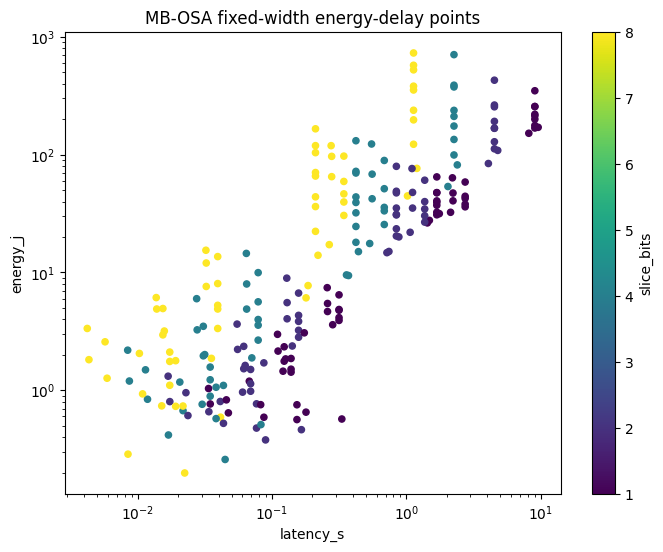

slice_bits,4
network,
alexnet,64
gpt2_medium,1160
mobilenet_v3,512
resnet18,168
vgg16,128
vision_transformer,784


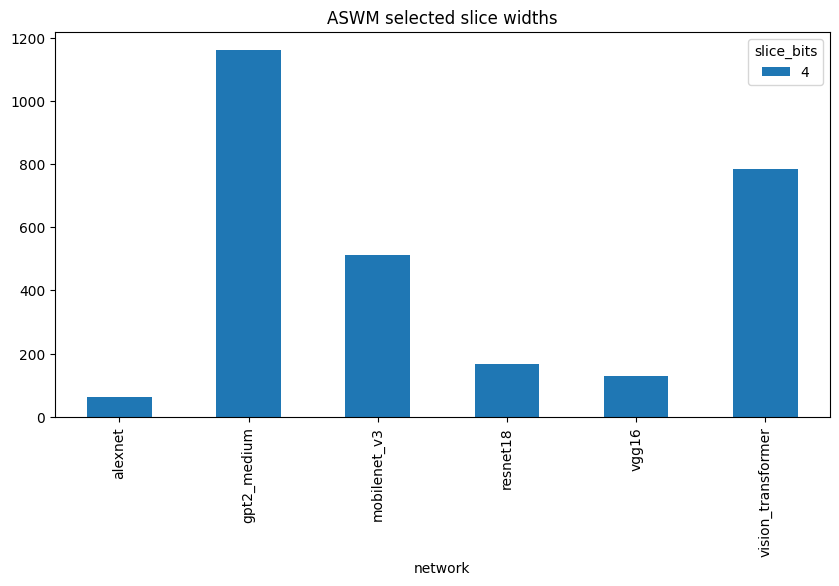

In [5]:
ax = primary_fixed.plot.scatter(x='latency_s', y='energy_j', c='slice_bits', colormap='viridis', logx=True, logy=True, figsize=(8, 6))
ax.set_title('MB-OSA fixed-width energy-delay points')
plt.show()
selection_counts = selections[(selections.energy_model == 'linear_bit') & (selections.optical_loss_db_per_stage == 0)].groupby(['network', 'slice_bits']).size().unstack(fill_value=0)
display(selection_counts)
selection_counts.plot.bar(stacked=True, figsize=(10, 5), title='ASWM selected slice widths')
plt.show()

## Sensitivity boundary
The optimistic constant-symbol and conservative Walden DAC models, together with 0/0.5/1 dB optical-loss compensation per delay stage, are modeling sensitivities—not measured accuracy results.

In [6]:
sensitivity = aswm.groupby(['energy_model', 'optical_loss_db_per_stage']).edp_j_s.agg(['min', 'median', 'max'])
display(sensitivity)

min    median  \
energy_model               optical_loss_db_per_stage                       
conservative_walden        0.0                        0.018261  8.905524   
                           0.5                        0.018284  8.906399   
                           1.0                        0.018315  8.907559   
linear_bit                 0.0                        0.009943  4.267496   
                           0.5                        0.009944  4.267804   
                           1.0                        0.009946  4.268150   
optimistic_constant_symbol 0.0                        0.003871  2.777865   
                           0.5                        0.003873  2.778173   
                           1.0                        0.003875  2.778519   

                                                              max  
energy_model               optical_loss_db_per_stage               
conservative_walden        0.0                        2662.755781  
                           0.5                        2664.389414  
                           1.0                        2666.696981  
linear_bit                 0.0                        1596.245626  
                           0.5                        1596.366833  
                           1.0                        1596.502829  
optimistic_constant_symbol 0.0                         513.967988  
                           0.5                         514.089195  
                           1.0                         514.225191